In [25]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from pathlib import Path
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from PIL import Image

In [27]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device:

 cpu


In [28]:
project_root = Path.cwd().parent

test_dir = project_root / "dataset" / "processed" / "test"
model_path = project_root / "models" / "efficientnet_b0_oral_cancer.pth"

print("Test directory:", test_dir)
print("Model path:", model_path)
print("Model exists:", model_path.exists())

Test directory: e:\PROJECTS\OralScan-AI\dataset\processed\test
Model path: e:\PROJECTS\OralScan-AI\models\efficientnet_b0_oral_cancer.pth
Model exists: True


In [29]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Classes:", test_dataset.classes)
print("Class mapping:", test_dataset.class_to_idx)
print("Test images:", len(test_dataset))

Classes: ['CANCER', 'NON CANCER']
Class mapping: {'CANCER': 0, 'NON CANCER': 1}
Test images: 93


In [31]:
checkpoint = torch.load(
    model_path,
    map_location=device
)

class_names = checkpoint["class_names"]
class_to_idx = checkpoint["class_to_idx"]

print("Saved class names:", class_names)
print("Saved class mapping:", class_to_idx)

Saved class names: ['CANCER', 'NON CANCER']
Saved class mapping: {'CANCER': 0, 'NON CANCER': 1}


In [32]:
model = models.efficientnet_b0(weights=None)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, len(class_names))
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [33]:
all_labels = []
all_predictions = []
all_probabilities = []
all_paths = []

with torch.no_grad():

    for batch_index, (images, labels) in enumerate(test_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

all_paths = [
    path
    for path, label in test_dataset.samples
]

print("Predictions generated:", len(all_predictions))

Predictions generated: 93


In [34]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%"
)

Test Accuracy: 0.8710
Test Accuracy Percentage: 87.10%


In [35]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      CANCER     0.8913    0.8542    0.8723        48
  NON CANCER     0.8511    0.8889    0.8696        45

    accuracy                         0.8710        93
   macro avg     0.8712    0.8715    0.8710        93
weighted avg     0.8718    0.8710    0.8710        93



In [36]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

Weighted Precision: 0.8718
Weighted Recall: 0.8710
Weighted F1-score: 0.8710


In [37]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  7]
 [ 5 40]]


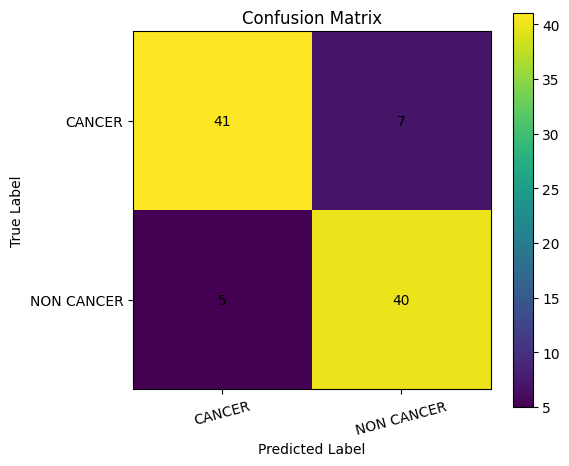

In [38]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=15
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        plt.text(
            column,
            row,
            cm[row, column],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [39]:
cancer_index = None

for class_name, class_index in class_to_idx.items():
    if "cancer" in class_name.lower() and "non" not in class_name.lower():
        cancer_index = class_index

print("Cancer class index:", cancer_index)

Cancer class index: 0


In [40]:
cancer_true = (
    all_labels == cancer_index
).astype(int)

cancer_predicted = (
    all_predictions == cancer_index
).astype(int)

cancer_cm = confusion_matrix(
    cancer_true,
    cancer_predicted
)

tn, fp, fn, tp = cancer_cm.ravel()

cancer_sensitivity = tp / (tp + fn)
cancer_specificity = tn / (tn + fp)

print("Cancer-focused confusion matrix:")
print(cancer_cm)

print(f"Cancer Sensitivity: {cancer_sensitivity:.4f}")
print(f"Cancer Specificity: {cancer_specificity:.4f}")

Cancer-focused confusion matrix:
[[40  5]
 [ 7 41]]
Cancer Sensitivity: 0.8542
Cancer Specificity: 0.8889


In [41]:
cancer_probabilities = all_probabilities[
    :,
    cancer_index
]

auc_score = roc_auc_score(
    cancer_true,
    cancer_probabilities
)

fpr, tpr, thresholds = roc_curve(
    cancer_true,
    cancer_probabilities
)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9292


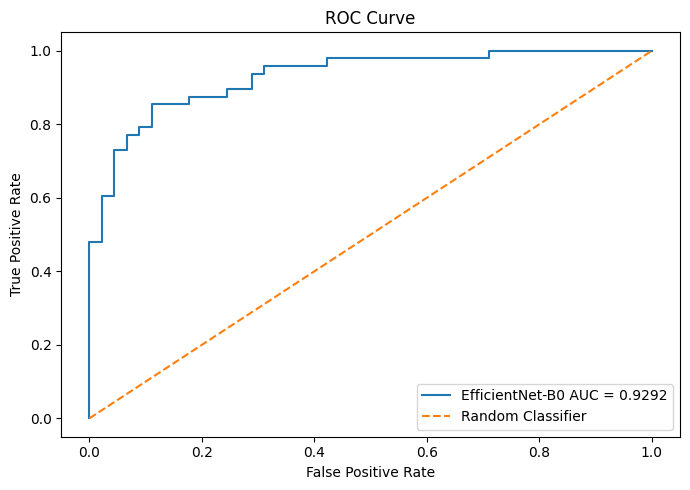

In [42]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"EfficientNet-B0 AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
misclassified_indices = np.where(
    all_labels != all_predictions
)[0]

print(
    "Total misclassified images:",
    len(misclassified_indices)
)

Total misclassified images: 12


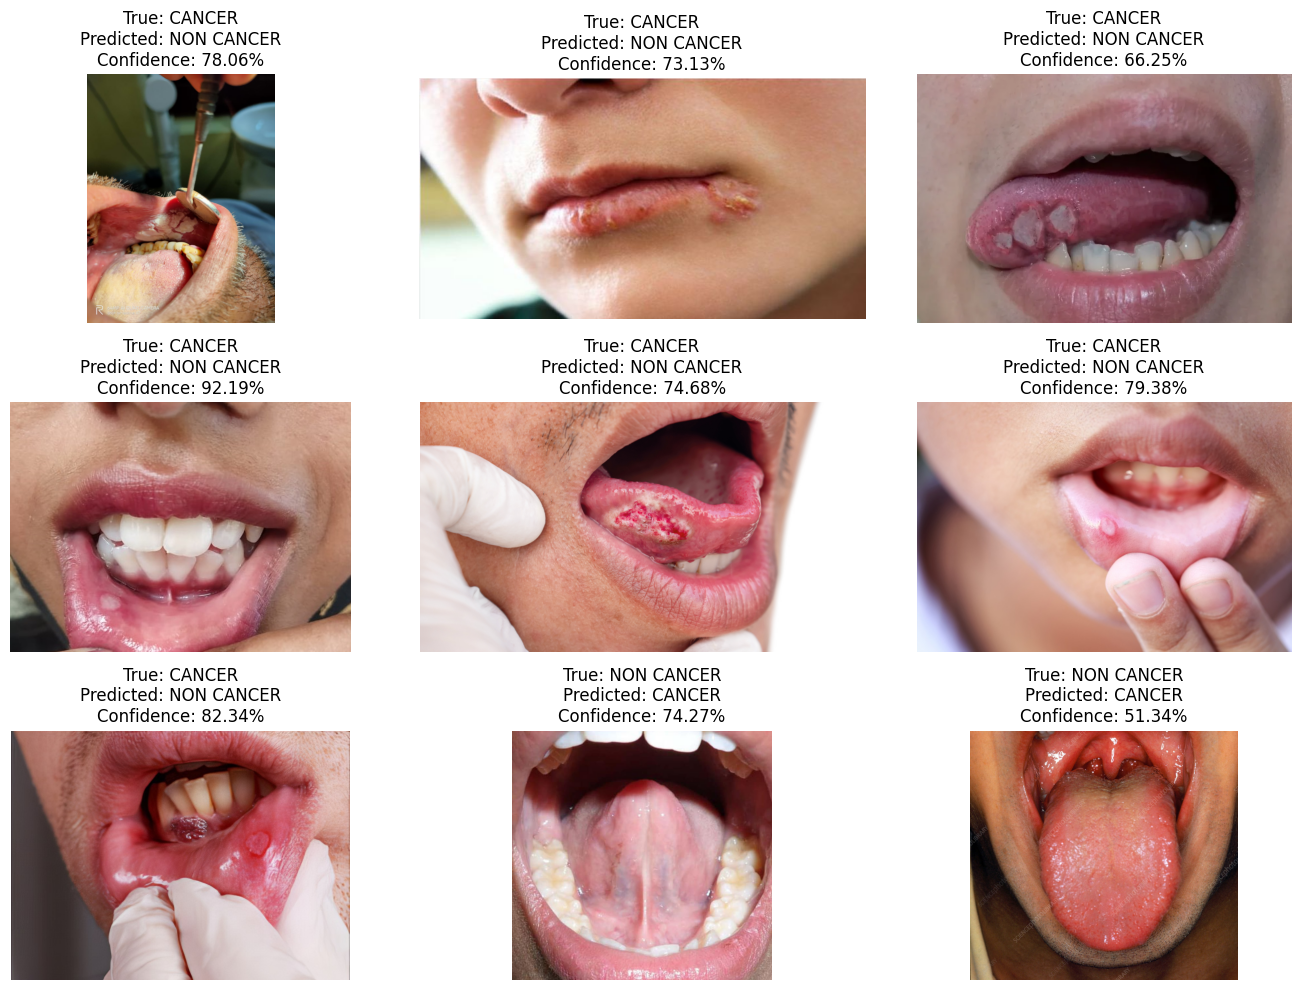

In [44]:
number_to_show = min(
    9,
    len(misclassified_indices)
)

plt.figure(figsize=(14, 10))

for plot_index in range(number_to_show):

    data_index = misclassified_indices[plot_index]
    image_path = all_paths[data_index]

    image = Image.open(image_path).convert("RGB")

    true_label = class_names[
        all_labels[data_index]
    ]

    predicted_label = class_names[
        all_predictions[data_index]
    ]

    confidence = all_probabilities[
        data_index,
        all_predictions[data_index]
    ]

    plt.subplot(3, 3, plot_index + 1)
    plt.imshow(image)

    plt.title(
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
print("=" * 50)
print("MODEL EVALUATION SUMMARY")
print("=" * 50)

print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")
print(f"Weighted Precision  : {precision:.4f}")
print(f"Weighted Recall     : {recall:.4f}")
print(f"Weighted F1-score   : {f1:.4f}")
print(f"Cancer Sensitivity  : {cancer_sensitivity:.4f}")
print(f"Cancer Specificity  : {cancer_specificity:.4f}")
print(f"ROC-AUC             : {auc_score:.4f}")

print("\nMedical disclaimer:")
print(
    "This model is intended only for preliminary research "
    "and screening support. It is not a medical diagnosis."
)

MODEL EVALUATION SUMMARY
Test Accuracy       : 87.10%
Weighted Precision  : 0.8718
Weighted Recall     : 0.8710
Weighted F1-score   : 0.8710
Cancer Sensitivity  : 0.8542
Cancer Specificity  : 0.8889
ROC-AUC             : 0.9292

Medical disclaimer:
This model is intended only for preliminary research and screening support. It is not a medical diagnosis.


In [46]:
results = f"""
MODEL EVALUATION SUMMARY
========================

Test Accuracy       : {test_accuracy*100:.2f}%
Weighted Precision  : {precision:.4f}
Weighted Recall     : {recall:.4f}
Weighted F1-score   : {f1:.4f}
Cancer Sensitivity  : {cancer_sensitivity:.4f}
Cancer Specificity  : {cancer_specificity:.4f}
ROC-AUC             : {auc_score:.4f}
"""

results_path = project_root / "models" / "evaluation_results.txt"

with open(results_path, "w") as file:
    file.write(results)

print("Results saved at:")
print(results_path)

Results saved at:
e:\PROJECTS\OralScan-AI\models\evaluation_results.txt


In [47]:
plt.savefig(
    project_root / "models" / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [48]:
plt.savefig(
    project_root / "models" / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>